# 1. Setup and Data Loading
Importing libraries and loading the dataset.

In [1]:
import pgeocode
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
import requests
import numpy as np
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from geopy.geocoders import Nominatim
import pmdarima as pm
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

In [66]:
df = pd.read_csv('complaints_sampled.csv')
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2024-12-10,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,XXXX Account Number : XXXX Balance : {$1500.00...,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,CA,92240,NaN,Web,2024-12-10,Closed with explanation,Yes,11080955.0
1,2026-01-10,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",NC,27127,NaN,Web,2026-01-10,Closed with explanation,Yes,18618561.0
2,2015-12-30,Debt collection,I do not know,Cont'd attempts collect debt not owed,Debt is not mine,I am a victim of Identity theft and I have sen...,NaN,AFNI INC.,CA,94621,NaN,Web,2015-12-30,Closed with explanation,Yes,1722629.0
3,2025-12-22,Vehicle loan or lease,Loan,Incorrect information on your report,Account information incorrect,NaN,NaN,"American Credit Acceptance, LLC",TN,38111,NaN,Referral,2025-12-22,Closed with explanation,Yes,18227443.0
4,2025-05-27,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"EQUIFAX, INC.",TN,37042,NaN,Web,2025-05-27,Closed with non-monetary relief,Yes,13761542.0


# 2. Data Preprocessing
Cleaning data, handling dates, and adding year columns.

In [67]:
#Add year column
#NaT if data is not able to be converted and drop those rows
df['Year'] = pd.to_datetime(df['Date received'], format='mixed', errors = 'coerce').dt.year
print('Shape of the dataframe before dropping year ', df.shape)
df = df.dropna(subset = 'Year')
print('Shape of the dataframe after dropping missing year ', df.shape)

Shape of the dataframe before dropping year  (3974125, 17)
Shape of the dataframe after dropping missing year  (3974124, 17)


# 3. Geocoding Data
Convert ZIP code to longitude and latitude.

In [68]:
nomi = pgeocode.Nominatim('us')

#replace X with 0 to get general location
df['ZIP code'] = df['ZIP code'].fillna('').str.replace('X', '0', regex=False)
unique_zips = df['ZIP code'].unique()
result = nomi.query_postal_code(unique_zips)

zip_to_lat = dict(zip(result['postal_code'], result['latitude']))
zip_to_lon = dict(zip(result['postal_code'], result['longitude']))

df['Latitude'] = df['ZIP code'].map(zip_to_lat)
df['Longitude'] = df['ZIP code'].map(zip_to_lon)

print(f"Geocoded {df['Latitude'].notna().sum():,} / {len(df):,} rows successfully")
#remove empty lat, long data
df = df.dropna(subset = ['Latitude', 'Longitude'])

Geocoded 3,655,185 / 3,974,124 rows successfully


# 4. Population Data
Add population for each state using Census datasets.

In [69]:
url_2019 = "https://www2.census.gov/programs-surveys/popest/datasets/2010-2019/national/totals/nst-est2019-alldata.csv"
url_2025 = "https://www2.census.gov/programs-surveys/popest/datasets/2020-2025/state/totals/NST-EST2025-ALLDATA.csv"

df19 = pd.read_csv(url_2019)
df25 = pd.read_csv(url_2025)

#Remove territories
df19 = df19[df19['SUMLEV'] == 40]
df25 = df25[df25['SUMLEV'] == 40]
print(f'Found {len(df19['NAME'].unique())} states/territories in df19 and {len(df25['NAME'].unique())} states/territories in df25')

Found 52 states/territories in df19 and 52 states/territories in df25


In [ ]:
region_df = df19.groupby(['REGION'])['NAME'].unique().reset_index()
region_dict = {}
for idx ,region in region_df.iterrows():
    print(f'Region {region['REGION']} consists of {region['NAME']}')
    for state in region['NAME']:
        region_dict[state] = region['REGION']



Region 1 consists of ['Connecticut' 'Maine' 'Massachusetts' 'New Hampshire' 'New Jersey'
 'New York' 'Pennsylvania' 'Rhode Island' 'Vermont']
Region 2 consists of ['Illinois' 'Indiana' 'Iowa' 'Kansas' 'Michigan' 'Minnesota' 'Missouri'
 'Nebraska' 'North Dakota' 'Ohio' 'South Dakota' 'Wisconsin']
Region 3 consists of ['Alabama' 'Arkansas' 'Delaware' 'District of Columbia' 'Florida'
 'Georgia' 'Kentucky' 'Louisiana' 'Maryland' 'Mississippi'
 'North Carolina' 'Oklahoma' 'South Carolina' 'Tennessee' 'Texas'
 'Virginia' 'West Virginia']
Region 4 consists of ['Alaska' 'Arizona' 'California' 'Colorado' 'Hawaii' 'Idaho' 'Montana'
 'Nevada' 'New Mexico' 'Oregon' 'Utah' 'Washington' 'Wyoming']
Region X consists of ['Puerto Rico']


In [71]:
cols_2025 = ['NAME'] + [f'POPESTIMATE{year}' for year in range(2020, 2026)]
cols_2019 = ['NAME'] + [f'POPESTIMATE{year}' for year in range(2011, 2020)]

df19 = df19[cols_2019]
df25 = df25[cols_2025]

pop_df = pd.merge(df19, df25, how='left', on ='NAME')
pop_df.columns = ['State'] + list(np.arange(2011,2026))
pop_df.head()

,State,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Alabama,4799069,4815588,4830081,4841799,4852347,4863525,4874486,4887681,4903185,5032962,5050058,5076868,5117850,5163055,5193088
1,Alaska,722128,730443,737068,736283,737498,741456,739700,735139,731545,732906,734590,733659,734654,736537,737270
2,Arizona,6472643,6554978,6632764,6730413,6829676,6941072,7044008,7158024,7278717,7186647,7274022,7370065,7452073,7556424,7623818
3,Arkansas,2940667,2952164,2959400,2967392,2978048,2989918,3001345,3009733,3017804,3014399,3027127,3047429,3069856,3096080,3114791
4,California,37638369,37948800,38260787,38596972,38918045,39167117,39358497,39461588,39512223,39527808,39152927,39125347,39181667,39364774,39355309


In [72]:
#Add abbreviated state names
state_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA', 
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA', 
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD', 
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO', 
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ', 
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC', 
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

pop_df = pop_df.melt(id_vars=  'State', var_name = 'Year', value_name='Population')
pop_df['State_abrr'] = pop_df['State'].map(state_abbr)
pop_df = pop_df.drop('State', axis = 1)
pop_df

,Year,Population,State_abrr
0,2011,4799069,AL
1,2011,722128,AK
2,2011,6472643,AZ
3,2011,2940667,AR
4,2011,37638369,CA
...,...,...,...
775,2025,8001020,WA
776,2025,1766147,WV
777,2025,5972787,WI
778,2025,588753,WY


In [73]:
map_df = df.copy()

unique_issues = map_df['Issue'].dropna().unique().tolist()

min_year = int(map_df['Year'].min()) 
max_year = int(map_df['Year'].max())
def interactive_map(issues, year):
    # Filter the df
    to_plot = map_df[(map_df['Year'] == year) & (map_df['Issue'].isin(issues))]
    
    # Check if the filtered dataframe is empty before plotting
    if to_plot.empty:
        print("No data available for the selected filters.")
        return
        
    fig = px.scatter_map(
        # sample at most 1000 points to avoid crashing if there are too many
        to_plot.sample(min(1000, len(to_plot))),
        lat='Latitude',
        lon='Longitude',
        hover_name='Sub-issue',
        color='Issue',
        zoom=3,
        center={"lat": 39, "lon": -98},  # Center on US
        map_style='carto-positron',
        height=600,
        width = 1200
    )    
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, title=f"Complaints Map in {year}")
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.show()

issues_widget = widgets.SelectMultiple(
    options=unique_issues,
    value=unique_issues[:3],  # Select first 3 by default
    description='Issues',
    disabled=False,
    rows=15,  
)
year_widget = widgets.IntSlider(
    value=max_year,
    min=min_year,
    max=max_year,
    step=1,
    description='Year',
    layout=widgets.Layout(width='800px'),
    continuous_update=False 
)

out = widgets.interactive_output(interactive_map, {'issues': issues_widget, 'year': year_widget})
# Left side gets the year slider and the map output stacked vertically
left_column = widgets.VBox([year_widget, out])
# The main UI puts the left column and the issues widget next to each other horizontally
ui = widgets.HBox([left_column, issues_widget])

display(ui)

# 5. Exploratory Data Analysis & Interactive Visualizations
Visualizing complaints using Plotly maps.

In [75]:
def plot_top_states(year):
    # Filter the dataframe for the selected year
    df_filtered = df[df['Year'] == year]
    
    top_15_states = df_filtered['State'].value_counts().nlargest(15).index
    top_15_df = df_filtered[df_filtered['State'].isin(top_15_states)]
    
    state_issue_count = top_15_df.groupby(['State', 'Issue'])['Complaint ID'].count().reset_index(name='Complaint Counts')
    state_issue_count = state_issue_count.sort_values(['State', 'Complaint Counts'], ascending=[True, False])
    
    # assign 'Other' to anything that isn't in the top 5 for that state
    state_issue_count['Rank'] = state_issue_count.groupby('State').cumcount() + 1
    state_issue_count['Issue'] = state_issue_count.apply(
        lambda row: row['Issue'] if row['Rank'] <= 5 else 'Other', axis=1
    )
    
    grouped_counts = state_issue_count.groupby(['State', 'Issue'])['Complaint Counts'].sum().reset_index()
    
    pivot_df = grouped_counts.pivot(index='State', columns='Issue', values='Complaint Counts').fillna(0)
    
    # Sort from most common complaints to least
    col_sums = pivot_df.sum().sort_values(ascending=False)
    cols = [c for c in col_sums.index if c != 'Other']
    if 'Other' in col_sums.index:
        cols.append('Other')  # Force 'Other' to be the very last column
    pivot_df = pivot_df[cols]
    
    pivot_df['Total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values(by='Total', ascending=True).drop(columns='Total')

    # Plot the stacked horizontal bar chart
    ax = pivot_df.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='tab20')
    
    plt.title(f'Top 15 States With Most Complaints in {year} by Issue', pad=15)
    plt.xlabel('Complaint Counts')
    plt.ylabel('State')
    
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    plt.legend(title='Issue', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

available_years = sorted(df['Year'].dropna().unique().astype(int))
# Create the interactive dropdown widget
interact(plot_top_states, year=widgets.IntSlider(
    value=available_years[0],
    min=available_years[0],
    max=available_years[-1], 
    description='Select Year:'
))

interactive(children=(IntSlider(value=2011, description='Select Year:', max=2026, min=2011), Output()), _dom_c…

<function __main__.plot_top_states(year)>

# Visualize Geographically 

In [76]:
# Convert to datetime and extract Year-Week for animation
df['Date received'] = pd.to_datetime(df['Date received'])
df['Year-Week'] = df['Date received'].dt.to_period('W').dt.start_time

# Group by month and state
monthly_state_counts = df.groupby(['Year','Year-Week', 'State']).size().reset_index(name='Complaints')
monthly_state_counts = monthly_state_counts.sort_values('Year-Week')
monthly_state_counts=monthly_state_counts.merge(pop_df, 
                        how = 'left', 
                        left_on=['Year','State'],
                        right_on=['Year','State_abrr']
                        )

# Drop any missing population and calculate complaints per 10,000 people
monthly_state_counts = monthly_state_counts.dropna(subset='Population')
monthly_state_counts['Complaints per 10k'] = monthly_state_counts['Complaints']/monthly_state_counts['Population'] * 10000

monthly_state_counts

,Year,Year-Week,State,Complaints,Population,State_abrr,Complaints per 10k
0,2011.0,2011-11-28,AL,1,4799069.0,AL,0.002084
1,2011.0,2011-11-28,WV,1,1856301.0,WV,0.005387
2,2011.0,2011-11-28,WI,2,5705288.0,WI,0.003506
3,2011.0,2011-11-28,WA,2,6826627.0,WA,0.002930
4,2011.0,2011-11-28,VA,6,8101155.0,VA,0.007406
...,...,...,...,...,...,...,...
35828,2025.0,2025-12-29,ND,3,799358.0,ND,0.037530
35829,2025.0,2025-12-29,NC,396,11197968.0,NC,0.353636
35830,2025.0,2025-12-29,MT,3,1144694.0,MT,0.026208
35831,2025.0,2025-12-29,OH,253,11900510.0,OH,0.212596


In [77]:
fig = px.choropleth(
    monthly_state_counts,
    locations='State',
    locationmode="USA-states",
    color='Complaints per 10k',
    animation_frame='Year-Week',  # Animates map week by week
    scope="usa",
    color_continuous_scale="Reds",
    title="Monthly Complaint Trends in 2025"
)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, width=1000, height=600)

fig.show(config = {'scrollZoom': False})

# 6. Time Series Analysis
- Decomposing the time series data for trend and seasonality.
- Decompose by region to see regional trends

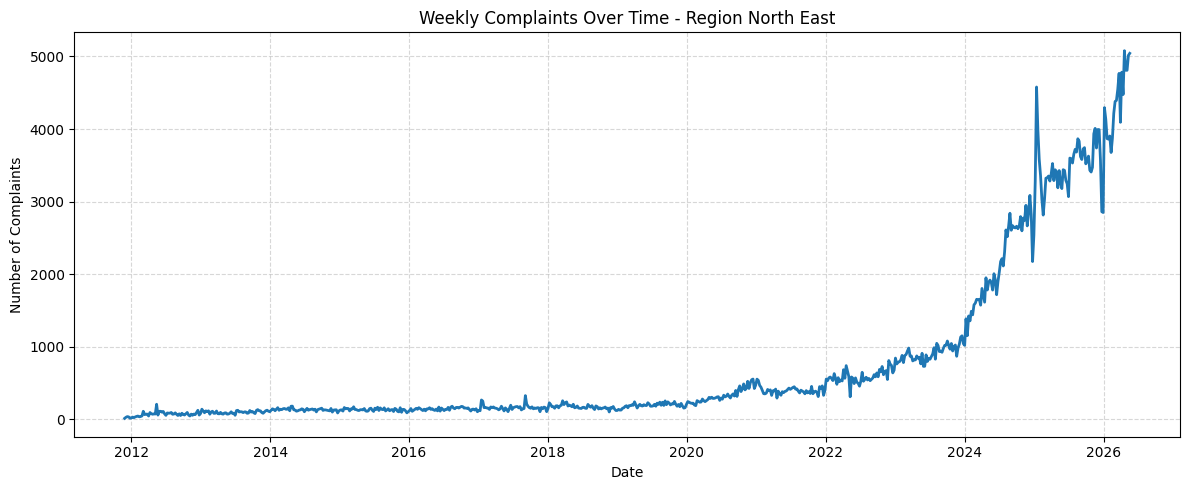

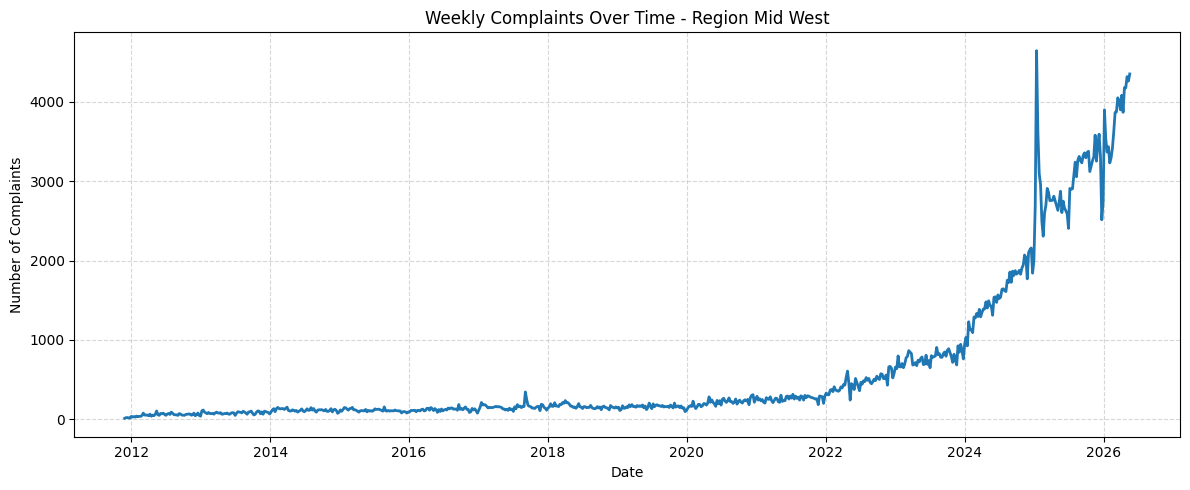

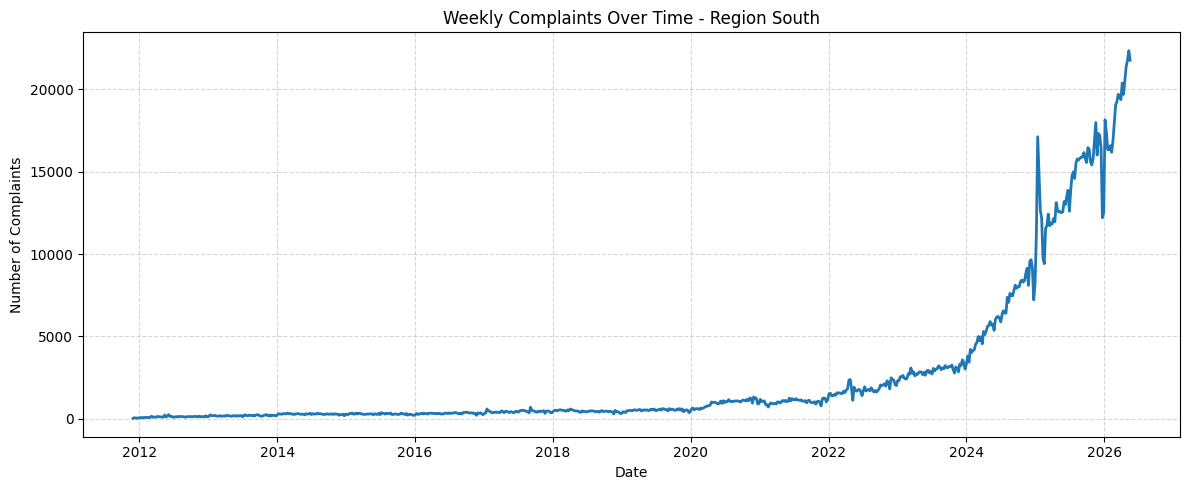

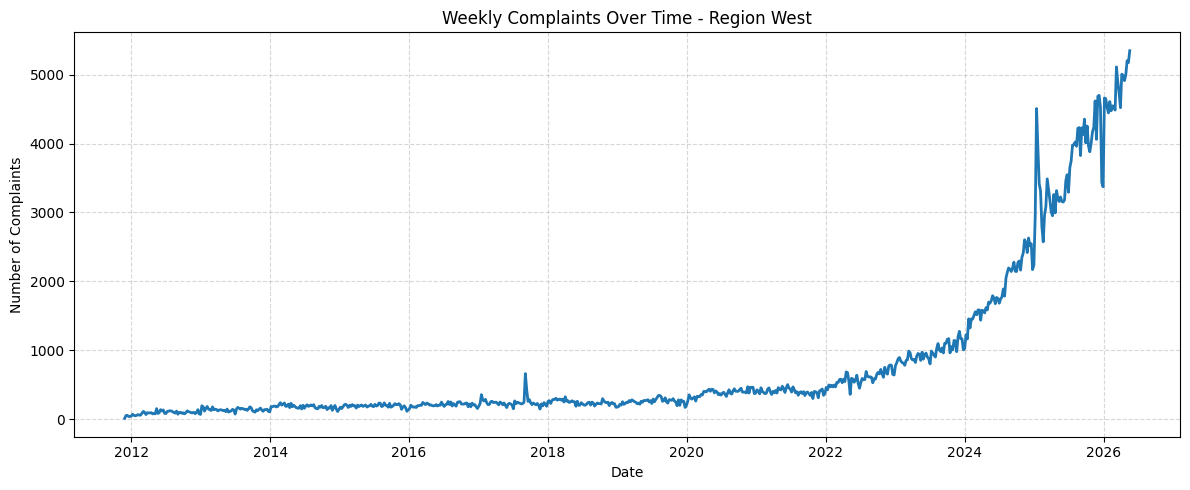

In [92]:
from matplotlib import lines
ts_df = df.copy()
ts_df['Date-Week'] = ts_df['Date received'].dt.to_period('W').dt.start_time


# Add full state name and region
ts_df['State_Full'] = ts_df['State'].map({v: k for k,v in state_abbr.items()})
ts_df['Region'] = ts_df['State_Full'].map(region_dict)

# Groupby region and date-week to count complaints
ts_df = ts_df.groupby(['Region','Date-Week'])['Complaint ID'].count().reset_index(name = 'Complaints')

# Calculate cutoff due to significant drop in complaints
total_weekly = ts_df.groupby('Date-Week')['Complaints'].sum().reset_index()
max_complaints_date = total_weekly.loc[total_weekly['Complaints'].idxmax(), 'Date-Week']
cutoff = max_complaints_date + timedelta(weeks = 1)

ts_df_cutoff = ts_df[ts_df['Date-Week'] <= cutoff]

# Generate figures for each region
regions = [region for region in ts_df['Region'].unique() if region != 'X']
trend_figs = []

region_label = {
        '1': 'North East',
        '2': 'Mid West',
        '3': 'South',
        '4': 'West'
}

for region in regions:
    filtered_ts_df = ts_df_cutoff[ts_df_cutoff['Region'] == region]
    
    fig,ax = plt.subplots(figsize = (12,5))
    ax.plot(filtered_ts_df['Date-Week'], filtered_ts_df['Complaints'],
            marker= None,
            linestyle = '-',
            markersize = 4,
            linewidth = 2)
    ax.set_title(f'Weekly Complaints Over Time - Region {region_label[region]}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Complaints')
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.5)
    trend_figs.append(fig)
    plt.show()
    

Total Seasonal Decomposition

C:\Users\Yooniversity 2.0\AppData\Local\Temp\ipykernel_20368\76916065.py:12: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



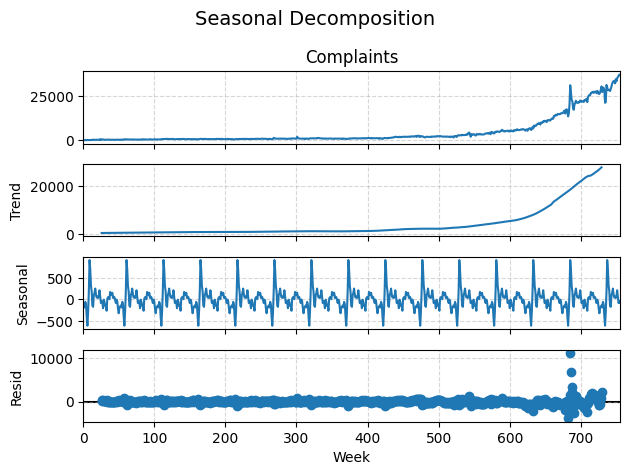

In [101]:
#Remove regionality and combine complaints by week
decomp_df = ts_df_cutoff.groupby('Date-Week')['Complaints'].sum().reset_index()

decomp = seasonal_decompose(decomp_df['Complaints'], model = 'additive', period = 52)
fig = decomp.plot()
fig.suptitle('Seasonal Decomposition', fontsize=14)
fig.axes[-1].set_xlabel('Week')
for ax in fig.axes:
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig.show()

## 6.1 Complaints Forecasting
Predicting the 2026 forecast using SARIMAX
- Train on 2022-2025 and forecast 2026
- Because all the regions showed similar trend and seasonality, we will forecast total complaints

In [103]:
# Group by region to count total complaints by week
ts_df_cutoff = ts_df_cutoff.groupby('Date-Week')['Complaints'].sum().reset_index()
ts_ds_pre = ts_df_cutoff[(ts_df_cutoff['Date-Week'].dt.year < 2026) & (ts_df_cutoff['Date-Week'].dt.year >= 2022)]
ts_ds_2026 = ts_df_cutoff[ts_df_cutoff['Date-Week'].dt.year == 2026]

print(f'The training date range is {ts_ds_pre['Date-Week'].min()} and {ts_ds_pre['Date-Week'].max()}')
print(f'The pre-2026 dataset has {ts_ds_pre.shape[0]} rows')

The training date range is 2022-01-03 00:00:00 and 2025-12-29 00:00:00
The pre-2026 dataset has 209 rows


Display Optimized Model using auto arima

In [104]:
from pmdarima.preprocessing import FourierFeaturizer

auto_model = pm.auto_arima(
    ts_ds_pre['Complaints'],
    start_p=1, max_p = 3,
    start_q = 1, max_q = 3,
    d = None,
    seasonal= True,
    m = 52, #datset is grouped by week
    start_P = 1, max_P= 2,
    start_Q = 1, max_Q = 2,
    D = 1,
    trace = True,
    stepwise = True, #set true for gridsearch
    StepwiseContext = 10 #test at max n searches
)
print(auto_model.summary())

print("Best order:", auto_model.order)
print("Best seasonal order:", auto_model.seasonal_order)


Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[52]             : AIC=2703.840, Time=18.88 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=2709.511, Time=0.45 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=2711.330, Time=1.88 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=2711.761, Time=2.17 sec
 ARIMA(1,1,1)(0,1,1)[52]             : AIC=2702.204, Time=7.34 sec
 ARIMA(1,1,1)(0,1,0)[52]             : AIC=2701.163, Time=0.62 sec
 ARIMA(1,1,1)(1,1,0)[52]             : AIC=2702.000, Time=7.45 sec
 ARIMA(0,1,1)(0,1,0)[52]             : AIC=2711.174, Time=0.20 sec
 ARIMA(1,1,0)(0,1,0)[52]             : AIC=2711.232, Time=0.16 sec
 ARIMA(2,1,1)(0,1,0)[52]             : AIC=2698.046, Time=1.42 sec
 ARIMA(2,1,1)(1,1,0)[52]             : AIC=2698.096, Time=7.47 sec
 ARIMA(2,1,1)(0,1,1)[52]             : AIC=2698.461, Time=6.97 sec
 ARIMA(2,1,1)(1,1,1)[52]             : AIC=2700.032, Time=11.54 sec
 ARIMA(2,1,0)(0,1,0)[52]             : AIC=2711.059, Time=0.23 sec
 ARIMA(3,1,1)(0,1

In [105]:
#predict using the optimized parameter
model = SARIMAX(ts_ds_pre['Complaints'],
                order = auto_model.order,
                seasonal_order= auto_model.seasonal_order)
result = model.fit(disp=False)

#Number of weeks to forecast
forecast_steps = 20
forecast_arima = result.get_forecast(steps = forecast_steps)
forecast_ci = forecast_arima.conf_int() #forecast confidence interval

# Build forecast index
forecast_idx = []
for week in range(1, forecast_steps +1):
    forecast_idx.append(ts_ds_pre['Date-Week'].max() + timedelta(weeks = week))

c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA paramet

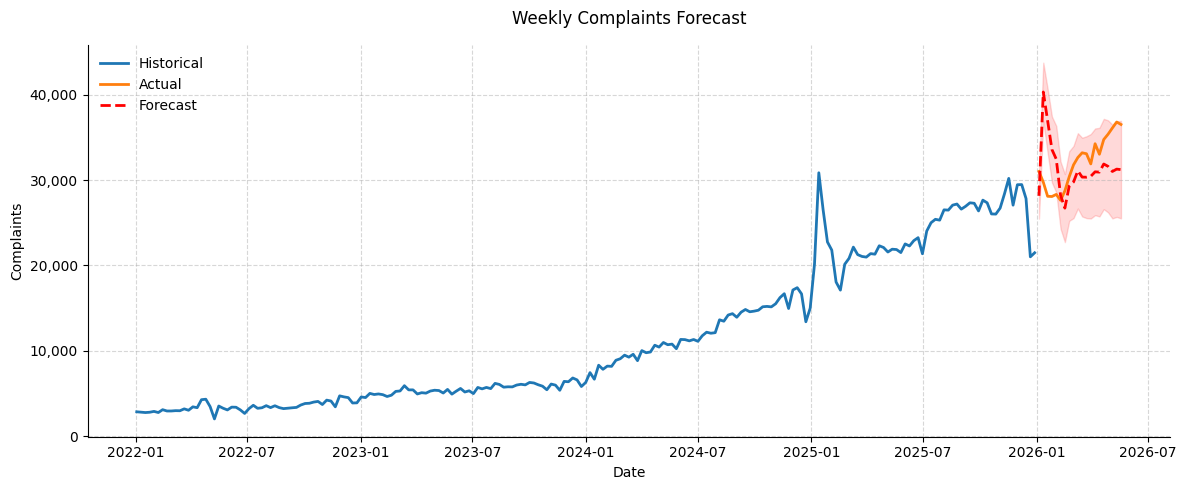

In [107]:
# Plot the forecast. only 2020-2026
begin_date = ts_ds_pre[ts_ds_pre['Date-Week'].dt.year >=2020]

plt.figure(figsize=(12, 5))
ax = plt.gca()

# Historical
plt.plot(begin_date['Date-Week'], begin_date['Complaints'], label='Historical', linewidth=2)
# Actual 2026
plt.plot(ts_ds_2026['Date-Week'], ts_ds_2026['Complaints'], label='Actual', linewidth=2)
# Forecast
plt.plot(forecast_idx, forecast_arima.predicted_mean.values, color='red', label='Forecast', linewidth=2, linestyle='--')
plt.fill_between(forecast_idx, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='red', alpha=0.15)

plt.title('Weekly Complaints Forecast', pad=15)
plt.xlabel('Date')
plt.ylabel('Complaints')

# Intuitive formatting
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

Forecasting using Prophet

In [124]:
# Prophet requires columns to be exactly named 'ds' (dates) and 'y' (values)
df_prophet = ts_ds_pre.reset_index()
df_prophet = df_prophet.rename(columns={'Date-Week': 'ds', 'Complaints': 'y'})
model_prophet = Prophet(yearly_seasonality=True) # Automatically handles the 52-week cycle
model_prophet.fit(df_prophet)

future = model_prophet.make_future_dataframe(periods=forecast_steps, freq='W')
forecast_prophet = model_prophet.predict(future)
fig1 = plot_plotly(model_prophet, 
                    forecast_prophet,
                    ylabel='Number of Complaints',
                    xlabel = 'Date'
)
fig2 = plot_components_plotly(model_prophet, forecast_prophet)

display(fig1), display(fig2)

18:13:26 - cmdstanpy - INFO - Chain [1] start processing
18:13:26 - cmdstanpy - INFO - Chain [1] done processing


c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python313\Lib\site-packages\plotly\io\_json.py:558: UserWarning:

Discarding nonzero nanoseconds in conversion.



(None, None)

## 6.2 Model Evaluation
Comparing actual and predicted complaints for validation.

In [125]:
pred_df = pd.DataFrame({
    'Date-Week':ts_ds_2026['Date-Week'],
    'Prediction': np.round(forecast_arima.predicted_mean.values[:20], 2),
    'Actual': ts_ds_2026['Complaints']
})

pred_df['Difference'] = pred_df['Actual'] - pred_df['Prediction']

pred_df

,Date-Week,Prediction,Actual,Difference
736,2026-01-05,28158.23,31008,2849.77
737,2026-01-12,40318.88,29753,-10565.88
738,2026-01-19,36964.64,28102,-8862.64
739,2026-01-26,33580.82,28076,-5504.82
740,2026-02-02,32456.03,28324,-4132.03
741,2026-02-09,28227.16,27630,-597.16
742,2026-02-16,26716.74,28735,2018.26
743,2026-02-23,29301.54,30381,1079.46
744,2026-03-02,29774.86,31780,2005.14
745,2026-03-09,31083.16,32643,1559.84


## 6.3 Forecast Evaluation Metrics
Calculate Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) to quantify the model's accuracy.

In [126]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate Evaluation Metrics using the overlapping 2026 predictions
mae = mean_absolute_error(pred_df['Actual'], pred_df['Prediction'])
rmse = np.sqrt(mean_squared_error(pred_df['Actual'], pred_df['Prediction']))
mape = np.mean(np.abs((pred_df['Actual'] - pred_df['Prediction']) / pred_df['Actual'])) * 100

print("FORECAST EVALUATION METRICS (2026) for ARIMA\n")
print(f"Mean Absolute Error (MAE):             {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE):        {rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


FORECAST EVALUATION METRICS (2026) for ARIMA

Mean Absolute Error (MAE):             3,706.39
Root Mean Squared Error (RMSE):        4,457.50
Mean Absolute Percentage Error (MAPE): 11.70%


In [127]:
forecast_prophet['ds'] = pd.to_datetime(forecast_prophet['ds'])  + pd.Timedelta(days = -1)
forecast_prophet_26 = forecast_prophet[forecast_prophet['ds'].dt.year == 2026]

# Calculate Evaluation Metrics using the overlapping 2026 predictions
mae = mean_absolute_error(forecast_prophet_26['trend'], pred_df['Prediction'])
rmse = np.sqrt(mean_squared_error(forecast_prophet_26['trend'], pred_df['Prediction']))
mape = np.mean(np.abs((pred_df['Actual'].values - forecast_prophet_26['trend'].values) / pred_df['Actual'].values)) * 100

print("FORECAST EVALUATION METRICS (2026) for Prophet\n")
print(f"Mean Absolute Error (MAE):             {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE):        {rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

FORECAST EVALUATION METRICS (2026) for Prophet

Mean Absolute Error (MAE):             2,748.28
Root Mean Squared Error (RMSE):        3,487.30
Mean Absolute Percentage Error (MAPE): 5.07%
